# PM2.5 Prediction using LSTM

- **Train:** 1 Mar - 2 Mar + 3 Mar - 4 Mar (100% training)
- **Test:** 5 Mar - 6 Mar
- **Input:** Time of day (HH:MM) -> **Output:** Predicted PM2.5 (ug/m3)

## 1. Imports

In [16]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 2. Load & Preprocess Data

In [17]:
def load_data(csv_files):
    """Load CSVs, pivot long-format into wide-format, compute time features."""
    raw = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
    raw['datetime'] = pd.to_datetime(raw['datetimeLocal']).dt.tz_localize(None)

    # Pivot: each parameter becomes its own column
    data = raw.pivot_table(index='datetime', columns='parameter', values='value', aggfunc='mean')
    data.sort_index(inplace=True)
    data.dropna(inplace=True)

    # Resample to regular 15-min intervals
    data = data.resample('15min').mean().interpolate(method='linear')

    # Rename for readability
    data.rename(columns={
        'pm10': 'PM10', 'pm25': 'PM25',
        'relativehumidity': 'RH', 'temperature': 'Temp',
        'wind_speed': 'Wind'
    }, inplace=True)

    # Cyclical time encoding
    hour = data.index.hour
    minute = data.index.minute
    total_min = hour * 60 + minute
    data['time_sin'] = np.sin(2 * np.pi * total_min / 1440)
    data['time_cos'] = np.cos(2 * np.pi * total_min / 1440)
    data['hour'] = hour
    data['minute'] = minute

    return data

## 3. Load Training & Test Data

In [18]:
train_data = load_data(['1 Mar - 2 Mar.csv', '3 Mar - 4 Mar.csv'])
print(f'Train: {len(train_data)} timestamps')
print(f'Date range: {train_data.index.min()} to {train_data.index.max()}')
print(f'PM2.5 range: {train_data["PM25"].min():.1f} - {train_data["PM25"].max():.1f}')

test_data = load_data(['5 Mar - 6 Mar.csv'])
print(f'\nTest: {len(test_data)} timestamps')
print(f'Date range: {test_data.index.min()} to {test_data.index.max()}')
print(f'PM2.5 range: {test_data["PM25"].min():.1f} - {test_data["PM25"].max():.1f}')

Train: 288 timestamps
Date range: 2026-03-01 05:45:00 to 2026-03-04 05:30:00
PM2.5 range: 50.0 - 111.0

Test: 95 timestamps
Date range: 2026-03-05 06:00:00 to 2026-03-06 05:30:00
PM2.5 range: 62.0 - 110.0


## 4. Visualize Training Data

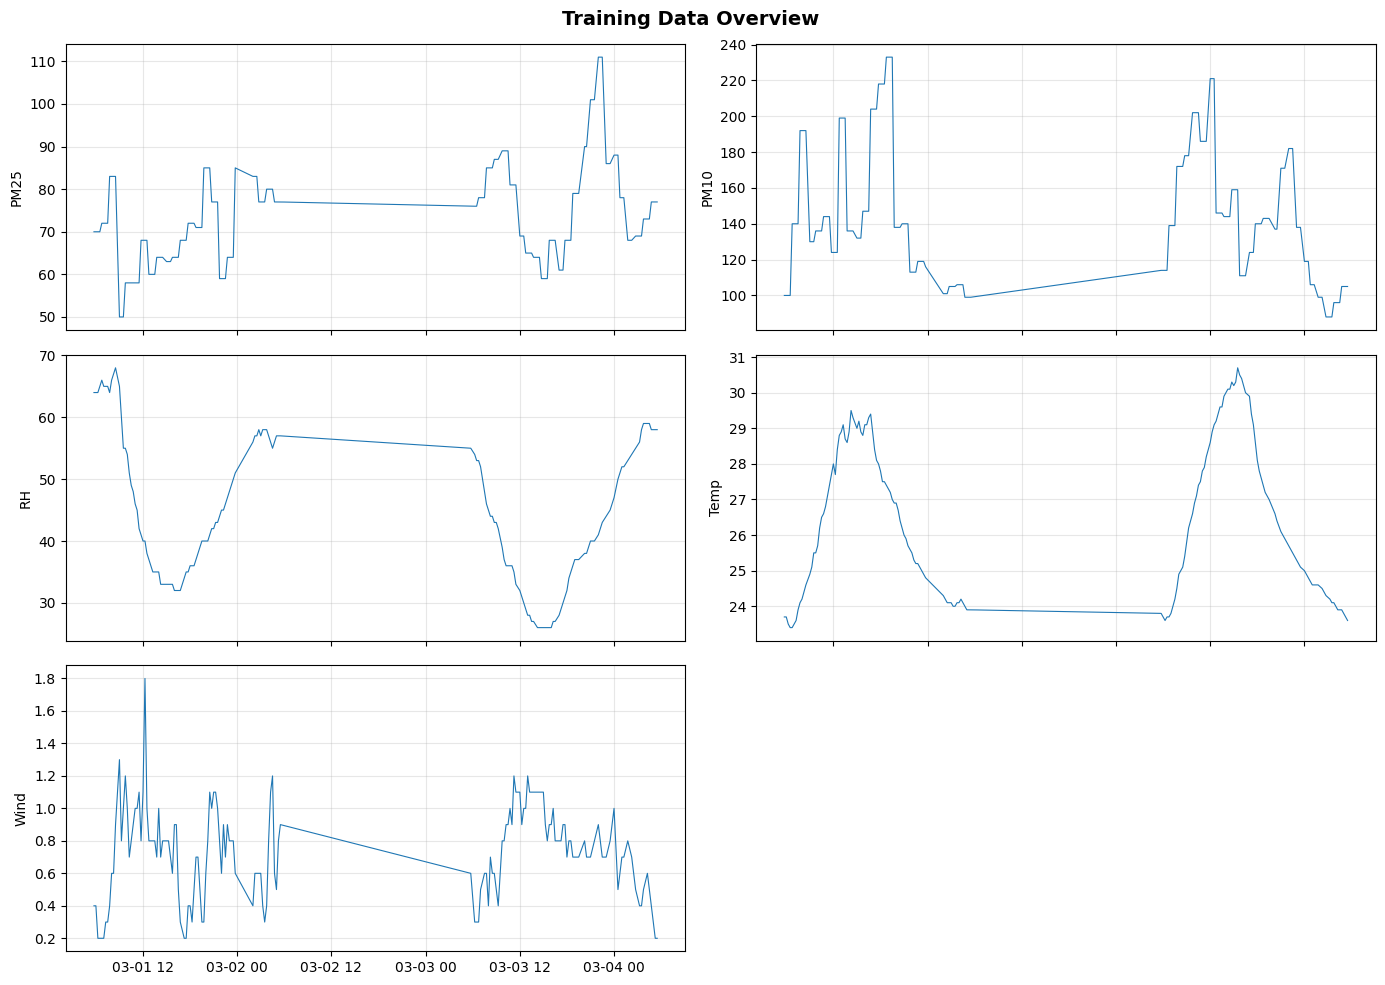

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
fig.suptitle('Training Data Overview', fontsize=14, fontweight='bold')
for ax, col in zip(axes.flat, ['PM25', 'PM10', 'RH', 'Temp', 'Wind']):
    ax.plot(train_data.index, train_data[col], linewidth=0.8)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

## 5. LSTM Model Definition

In [20]:
class AQI_LSTM(nn.Module):
    """LSTM model for PM2.5 prediction."""
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

## 6. Data Preparation & Sequence Creation

In [21]:
# Features: time encoding + environmental variables (PM25 included for historical context)
FEATURES = ['time_sin', 'time_cos', 'PM10', 'PM25', 'RH', 'Temp', 'Wind']
SEQ_LEN = 8

train_features = train_data[FEATURES].values.astype(np.float32)
train_target = train_data['PM25'].values.astype(np.float32)

# Normalise using training statistics
feat_mean = train_features.mean(axis=0)
feat_std = train_features.std(axis=0) + 1e-8
tgt_mean = train_target.mean()
tgt_std = train_target.std() + 1e-8

train_features_norm = (train_features - feat_mean) / feat_std
train_target_norm = (train_target - tgt_mean) / tgt_std

print(f'Features : {FEATURES}')
print(f'Seq len  : {SEQ_LEN}')
print(f'Samples  : {len(train_features)}')

Features : ['time_sin', 'time_cos', 'PM10', 'RH', 'Temp', 'Wind']
Seq len  : 4
Samples  : 288


In [22]:
def make_sequences(features, targets, times, seq_len):
    """Create overlapping sequences, enforcing strict 15-min intervals.
    If a gap > 15m exists in the window, the sequence is discarded."""
    X, y = [], []
    expected_delta = pd.Timedelta(minutes=15)
    
    for i in range(len(features) - seq_len):
        # Check continuity: the time difference between the first and last step
        # of this sequence + target should be exactly seq_len * 15 mins
        time_window = times[i : i + seq_len + 1]  # +1 to include target time
        time_diffs = pd.Series(time_window).diff().dropna()
        
        # If any interval is NOT 15 mins, skip this sequence completely
        if (time_diffs != expected_delta).any():
            continue
            
        X.append(features[i:i+seq_len])
        y.append(targets[i+seq_len])
        
    return np.array(X), np.array(y)

# Pass the index (times) into the sequence builder
X_train, y_train = make_sequences(train_features_norm, train_target_norm, train_data.index, SEQ_LEN)
print(f"Training sequences: {X_train.shape[0]}")


Training sequences: 284


## 7. Train the Model

In [23]:
EPOCHS = 150
LR = 0.001
BATCH = 16

X_t = torch.FloatTensor(X_train)
y_t = torch.FloatTensor(y_train)
loader = DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH, shuffle=True)

model = AQI_LSTM(input_size=len(FEATURES))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

# Training loop (100% training data)
losses = []
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for bx, by in loader:
        optimizer.zero_grad()
        pred = model(bx)
        loss = criterion(pred, by)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * bx.size(0)
    epoch_loss /= len(X_train)
    losses.append(epoch_loss)
    scheduler.step(epoch_loss)
    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:>4d}/{EPOCHS} | Loss: {epoch_loss:.6f}')

print('\nTraining complete.')

Epoch    1/150 | Loss: 1.008628
Epoch   25/150 | Loss: 0.221561
Epoch   50/150 | Loss: 0.144526
Epoch   75/150 | Loss: 0.106586
Epoch  100/150 | Loss: 0.097217
Epoch  125/150 | Loss: 0.052986
Epoch  150/150 | Loss: 0.049649

Training complete.


## 8. Training Loss

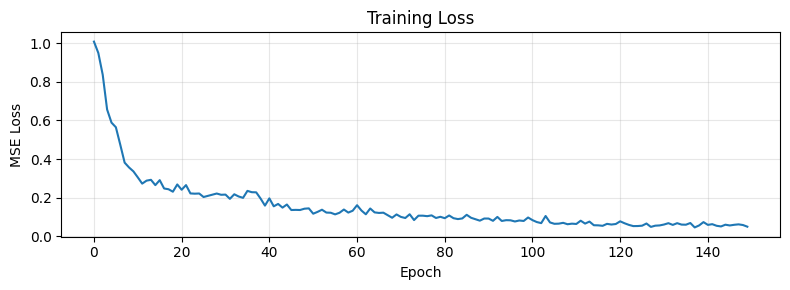

In [24]:
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Evaluate on Test Data

In [25]:
# Prepare test sequences using TRAINING normalisation stats
test_features = test_data[FEATURES].values.astype(np.float32)
test_target = test_data['PM25'].values.astype(np.float32)
test_features_norm = (test_features - feat_mean) / feat_std
test_target_norm = (test_target - tgt_mean) / tgt_std

X_test, y_test = make_sequences(test_features_norm, test_target_norm, test_data.index, SEQ_LEN)

model.eval()
with torch.no_grad():
    preds_norm = model(torch.FloatTensor(X_test)).numpy()

# De-normalise
preds = preds_norm * tgt_std + tgt_mean
actual = y_test * tgt_std + tgt_mean

mae = np.mean(np.abs(preds - actual))
rmse = np.sqrt(np.mean((preds - actual) ** 2))
print(f'Test MAE  : {mae:.2f} ug/m3')
print(f'Test RMSE : {rmse:.2f} ug/m3')

Test MAE  : 7.44 ug/m3
Test RMSE : 9.36 ug/m3


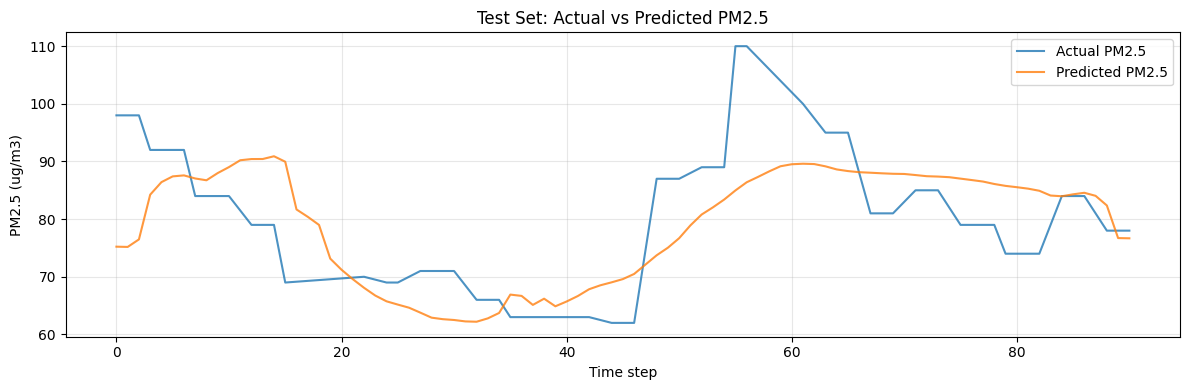

In [26]:
plt.figure(figsize=(12, 4))
plt.plot(actual, label='Actual PM2.5', alpha=0.8)
plt.plot(preds, label='Predicted PM2.5', alpha=0.8)
plt.xlabel('Time step')
plt.ylabel('PM2.5 (ug/m3)')
plt.title('Test Set: Actual vs Predicted PM2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. PM2.5 Category Function

In [27]:
def get_pm25_category(pm25):
    """Map PM2.5 to Indian AQI category (PM2.5 breakpoints)."""
    if pm25 <= 30: return 'Good'
    elif pm25 <= 60: return 'Satisfactory'
    elif pm25 <= 90: return 'Moderate'
    elif pm25 <= 120: return 'Poor'
    elif pm25 <= 250: return 'Very Poor'
    else: return 'Severe'

## 11. Predict for Time Function

In [28]:
def predict_for_time(time_str):
    """Predict PM2.5 for a given time string (HH:MM)."""
    h, m = map(int, time_str.strip().split(':'))
    total_min = h * 60 + m
    t_sin = np.sin(2 * np.pi * total_min / 1440)
    t_cos = np.cos(2 * np.pi * total_min / 1440)

    # Find nearby training data points (+/- 60 min)
    train_copy = train_data.copy()
    train_copy['total_min'] = train_copy['hour'] * 60 + train_copy['minute']
    time_diff = np.abs(train_copy['total_min'] - total_min)
    time_diff = np.minimum(time_diff, 1440 - time_diff)

    nearby = train_copy[time_diff <= 60]
    if len(nearby) == 0:
        nearby = train_copy[time_diff <= 120]

    # Build input sequence
    if len(nearby) >= SEQ_LEN:
        closest = nearby.iloc[time_diff[time_diff <= 60].argsort().values[:SEQ_LEN]]
        seq = closest[FEATURES].values.astype(np.float32)
    else:
        avg = nearby[FEATURES].mean().values.astype(np.float32)
        avg[0], avg[1] = t_sin, t_cos
        seq = np.tile(avg, (SEQ_LEN, 1))

    # Normalise and predict
    seq_norm = (seq - feat_mean) / feat_std
    model.eval()
    with torch.no_grad():
        pred = model(torch.FloatTensor(seq_norm).unsqueeze(0)).item()
    return max(0, pred * tgt_std + tgt_mean)

## 11.5 Export Model to Pickle

In [29]:
import pickle, os

export_data = {
    'model_state_dict': model.state_dict(),
    'input_size': len(FEATURES),
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'features': FEATURES,
    'seq_len': SEQ_LEN,
    'feat_mean': feat_mean,
    'feat_std': feat_std,
    'tgt_mean': tgt_mean,
    'tgt_std': tgt_std,
    'train_data_dict': train_data.reset_index().to_dict('list'),
}

pkl_path = os.path.join(os.getcwd(), 'pm25_model.pkl')
with open(pkl_path, 'wb') as f:
    pickle.dump(export_data, f)

print(f'Model exported to {pkl_path}')
print(f'File size: {os.path.getsize(pkl_path) / 1024:.1f} KB')

Model exported to c:\Users\Shrey\Desktop\DL_ETE\pm25_model.pkl
File size: 239.4 KB


## 12. Interactive Prediction

In [30]:
# ============================
time_input = '14:30'
# ============================

pm25 = predict_for_time(time_input)
print(f'Time     : {time_input}')
print(f'PM2.5    : {pm25:.1f} ug/m3')
print(f'Category : {get_pm25_category(pm25)}')

Time     : 14:30
PM2.5    : 64.5 ug/m3
Category : Moderate
